## W25-3248: Stress Testing using SFNO model

- Earth2-focused project in conjunction with RML 
- Examine extreme rainfall event(s) that impacted Dublin, Ireland in summer 2007 
- The high-level aim is to set up AI-based weather forecasts to develop counterfactual analyses (i.e. are there plausible scenarios that could have made a historical flooding event even worse)

In [1]:
import numpy as np
import xarray as xr 
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.dates import MonthLocator, DateFormatter, YearLocator
import seaborn as sns
sns.set_theme()

### Read in relevant precip data 

- Observations
    - E-OBS gridded daily precipitation dataset (Copernicus)
    - GPM-IMERG satellite-based daily precipitation dataset (NASA)
    - Met Eireann station observations (6 stations within Dublin) 
- Forecast data 
    - TIGGE archive (ECMWF and UKMO ensemble forecasts)
    - 50 ensemble members run twice daily (00 and 12Z) out to T+168 (7 days)
- Processing 
    - Create a time-series to determine which dates stand out 
    - Subset to the UK and Ireland 

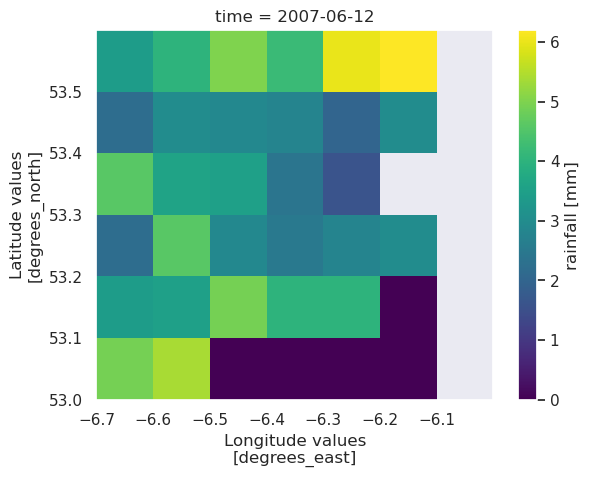

In [2]:
data_path = '/mnt/metdata/W25-3248/'
station_name = 'merrion_square'
station_ID = '3923'
eobs_precip = xr.open_dataset(f'{data_path}/rr_ens_mean_0.1deg_reg_1995-2010_v30.0e.nc')

# TODO: work out the most representative grid box 
eobs_precip = eobs_precip.sel(time=slice('2007-06-01','2007-08-31'),
                              latitude=slice(53.0, 53.6),
                              longitude=slice(-6.7, -6.0))

dublin_eobs_daily = eobs_precip['rr'].mean(dim=('latitude','longitude'))
dublin_eobs_daily.quantile(0.95)
eobs_precip['rr'].sel(time='2007-06-12').plot()

### START FROM HERE 

- TODO: pick a representative region to subset the gridded data 
- TODO: identify the most extreme rainfall events in the E-OBS and GPM-IMERG data
- TODO: check for agreement between gridded datasets and observations 
- TODO: once rainfall extremes have been identified, analyse the ensemble forecasts for the chosen dates 

In [3]:
station_dict = {'ringsend': 
                    {'station_ID':'2523',
                     'header_ID': 6
                     },
                'merrion_square': 
                    {'station_ID':'3923',
                     'header_ID': 10
                     },
                'glasnevin': 
                    {'station_ID':'1823',
                     'header_ID': 10 
                     },
               #  'phoenix_park': 
               #      {'station_ID': '175',
               #       'header_ID': 11
               #       },
                'ballyboden': 
                    {'station_ID': '6623',
                     'header_ID': 6
                     },
                'dun_laoghaire': 
                    {'station_ID': '9223',
                     'header_ID': 10
                     }
                }

/tmp/ipykernel_3552917/3358370410.py:14: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  station_data = pd.read_csv(station_data_path,
/tmp/ipykernel_3552917/3358370410.py:14: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  station_data = pd.read_csv(station_data_path,
/tmp/ipykernel_3552917/3358370410.py:14: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  station_data = pd.read_csv(station_data_path,
/tmp/ipykernel_3552917/3358370410.py:14: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consisten

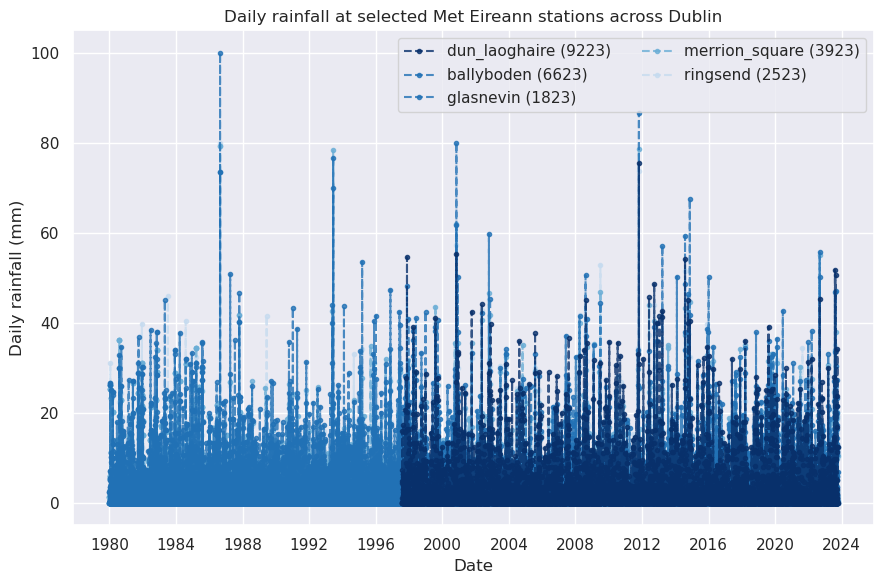

In [6]:
fig, ax = plt.subplots(figsize=(9,6))

colours = plt.get_cmap('Blues', len(station_dict))
blues = colours(np.linspace(0.35, 0.9, len(station_dict)))
start_date = '1980-01-01'
end_date = '2023-10-01'
index = 0
station_list = []

for station_name, station_info in station_dict.items():
    station_ID = station_info['station_ID']
    header_ID = station_info['header_ID']
    station_data_path = f'{data_path}/dly{station_ID}_{station_name}/dly{station_ID}.csv'
    station_data = pd.read_csv(station_data_path,
                               header=header_ID,
                               parse_dates=['date'])
    station_data = station_data[['date','rain']]
    station_data = station_data[(station_data['date'] >= start_date) & (station_data['date'] <= end_date)]
    station_list.append(station_data)

    ax.plot(station_data['date'],
            station_data['rain'],
            linestyle='--',
            marker='o',
            markersize=3,
            color=blues[index], # 0.3
            alpha=0.8,
            label=f'{station_name} ({station_ID})')
    
    index += 1

# -------- cosmetic tweaks --------
ax.set_ylabel(f'Daily rainfall (mm)') # (mm day$^{-1}$)')
ax.set_xlabel('Date')
ax.set_title(f'Daily rainfall at selected Met Eireann stations across Dublin')

# nicer x-axis ticks
#ax.xaxis.set_major_locator(MonthLocator(interval=1))            # Labels each month
ax.xaxis.set_major_locator(YearLocator(base=4))            # Labels each month
ax.xaxis.set_major_formatter(DateFormatter('%Y'))

# Put legend in order: wet months first
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1], 
          frameon=True,
          ncol=2,
          loc='upper right')

plt.tight_layout()
plt.savefig(f'{data_path}/output_plots/daily_rainfall_time_series_1980_2023_Dublin.png',dpi=300)

In [111]:
for station_df in station_list:
    imax = station_df['rain'].idxmax()
    row = station_df.loc[imax]
    date_of_max_rainfall = row['date']
    max_rainfall = row['rain']
    print(date_of_max_rainfall,max_rainfall)

2007-07-22 00:00:00 24.4
2007-06-02 00:00:00 24.8
2007-06-02 00:00:00 28.5
2007-06-03 00:00:00 37.2
2007-08-04 00:00:00 36.6
